# Generate figures for animation of SASSIE domain

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import glob
import warnings
from pathlib import Path
import s3fs
from pprint import pprint
import matplotlib
from matplotlib.backends.backend_pdf import PdfPages
from tqdm import tqdm
import cmocean
import os

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:41411")
client

<Client: 'tcp://127.0.0.1:41411' processes=8 threads=32, memory=123.95 GiB>

### Open 3D model fields

In [3]:
# function to open zarr store with a provided s3 bucket path

def open_zarr_store(s3_path):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(anon=False)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

In [4]:
# open SALT zarr store
salt_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/')

# open THETA zarr store
theta_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/')

# open SEA ICE AREA zarr store
SIarea_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/')

# open SEA ICE AREA zarr store
qnet_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/EXFqnet_AVG_DAILY.ZARR/')

In [69]:
qnet_zarr

<xarray.Dataset> Size: 40GB
Dimensions:    (time: 2581, j: 1080, i: 1800, nv: 2)
Coordinates:
    XC         (j, i) float32 8MB -128.0 -128.0 -128.0 ... 51.96 51.96 51.96
    YC         (j, i) float32 8MB 48.68 48.73 48.78 48.83 ... 63.41 63.37 63.34
  * i          (i) int32 7kB 0 1 2 3 4 5 6 ... 1794 1795 1796 1797 1798 1799
  * j          (j) int32 4kB 0 1 2 3 4 5 6 ... 1074 1075 1076 1077 1078 1079
  * time       (time) datetime64[ns] 21kB 2014-01-15T12:00:00 ... 2021-02-07T...
    time_bnds  (time, nv) datetime64[ns] 41kB dask.array<chunksize=(2581, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    EXFqnet    (time, j, i) float64 40GB dask.array<chunksize=(1, 270, 450), meta=np.ndarray>
Attributes: (12/50)
    Conventions:               CF-1.8, ACDD-1.3
    acknowledgement:           This research was carried out by the Jet Propu...
    author:                    Mike Wood, Marie Zahn, and Ian Fenty
    cdm_data_type:             Grid
    comment:                   SASSIE llc1080 V1R1 fields are consolidated on...
    creator_email:             ecco-group@mit.edu
    ...                        ...
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    summary:                   This dataset provides data variable and geomet...
    time_coverage_end:         2021-02-08T00:00:00
    time_coverage_start:       2014-01-15T00:00:00
    title:                     SASSIE Ocean Model EXFqnet Parameter for the L...
    uuid:                      a2405556-1340-11ef-b623-0604868e061f

## Make figure with SSS and sea ice on top, then same for SST

In [15]:
date = '2020-10-15'

In [16]:
SIarea_ds = (SIarea_zarr.sel(time=date).SIarea*100).load()
salt_ds = salt_zarr.sel(time=date).isel(k=0).SALT.load()
theta_ds = theta_zarr.sel(time=date).isel(k=0).THETA.load()
qnet_ds = (qnet_zarr.sel(time=date).EXFqnet*-1).load() # make qnet positive downward so >0 increases theta

In [17]:
# mask out grid cells where sea ice is < 15%
SIarea_over15 = SIarea_ds.where(SIarea_ds>15,np.nan)
salt_ice_mask = salt_ds.where(SIarea_ds<15,np.nan)
temp_ice_mask = theta_ds.where(SIarea_ds<15,np.nan)
qnet_ice_mask = qnet_ds.where(SIarea_ds<15,np.nan)

In [18]:
# salt_flip = xr.DataArray(np.rot90(salt_ice_mask.isel(i=slice(450,700),j=slice(0,500),time=0),3), dims=['i','j'])
# temp_flip = xr.DataArray(np.rot90(temp_ice_mask.isel(i=slice(450,700),j=slice(0,500),time=0),3), dims=['i','j'])
# si_flip = xr.DataArray(np.rot90(SIarea_over15.isel(i=slice(450,700),j=slice(0,500),time=0),3), dims=['i','j'])
# qnet_flip = xr.DataArray(np.rot90(qnet_ice_mask.isel(i=slice(450,700),j=slice(0,500),time=0),3), dims=['i','j'])

In [20]:
salt_flip = xr.DataArray(np.rot90(salt_ice_mask.isel(i=slice(450,750),j=slice(110,390),time=0),3), dims=['i','j'])
temp_flip = xr.DataArray(np.rot90(temp_ice_mask.isel(i=slice(450,750),j=slice(110,390),time=0),3), dims=['i','j'])
si_flip = xr.DataArray(np.rot90(SIarea_over15.isel(i=slice(450,750),j=slice(110,390),time=0),3), dims=['i','j'])
qnet_flip = xr.DataArray(np.rot90(qnet_ice_mask.isel(i=slice(450,750),j=slice(110,390),time=0),3), dims=['i','j'])

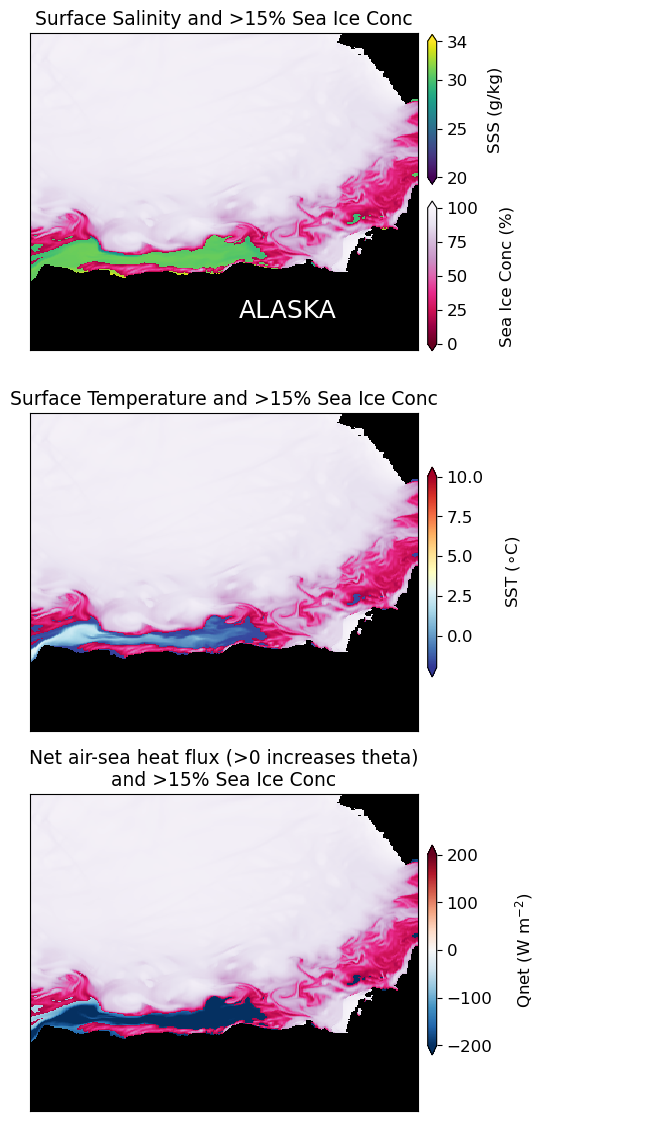

In [49]:
plt.rcParams.update({'font.size': 12})
fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=[5,14])

# SSS
salt_cmap = salt_flip.plot(ax=ax1,vmin=20,vmax=34,cmap='viridis',add_colorbar=False)
si_cmap = si_flip.plot(ax=ax1,vmin=0,vmax=100,cmap='PuRd_r',add_colorbar=False)
# ax1.set_title("SASSIE ECCO llc1080 Ocean Model\n\nSurface Salinity and >15% Sea Ice Conc",fontsize=13.5);
ax1.set_title("Surface Salinity and >15% Sea Ice Conc",fontsize=13.5);

# SST
temp_cmap = temp_flip.plot(ax=ax2,vmin=-2,vmax=10,cmap='RdYlBu_r',add_colorbar=False)
si_flip.plot(ax=ax2,vmin=0,vmax=100,cmap='PuRd_r',add_colorbar=False)
ax2.set_title("Surface Temperature and >15% Sea Ice Conc",fontsize=13.5);

# qnet
qnet_cmap = qnet_flip.plot(ax=ax3,vmin=-200,vmax=200,cmap='RdBu_r',add_colorbar=False)
si_flip.plot(ax=ax3,vmin=0,vmax=100,cmap='PuRd_r',add_colorbar=False)
ax3.set_title("Net air-sea heat flux (>0 increases theta)\nand >15% Sea Ice Conc",fontsize=13.5);

# add text for date
date_str = str(salt_ds.time.values)
date = date_str[7:10] + date_str[10:12] + '-' + date_str[2:6]
ax1.text(370,30,f'{date}',size=14,color='white')

# # add text for date
# date_str = str(theta_ds.time.values)
# date = date_str[7:10] + date_str[10:12] + '-' + date_str[2:6]
# ax2.text(370,35,f'{date}',size=14,color='white')

# add text for date
# date_str = str(qnet_ds.time.values)
# date = date_str[7:10] + date_str[10:12] + '-' + date_str[2:6]
# ax3.text(370,35,f'{date}',size=14,color='white')

# add text for depth
# ax1.text(370,20,'Z = -0.5 m',size=14,color='white')

# add label for Alaska
ax1.text(150,30,'ALASKA',size=18, color='white')

for ax in (ax1,ax2,ax3):
    # make background black
    ax.set_facecolor('k')

    # remove tick labels
    ax.set_xticklabels([])
    ax.set_yticklabels([]);
    ax.tick_params(left = False, bottom = False) 
    ax.set_xlabel("")
    ax.set_ylabel("");

    # # add text for depth
    # ax.text(370,20,'Z = -0.5 [m]',size=14,color='white')
    
    # # add label for Alaska
    # ax.text(150,30,'ALASKA',size=18, color='white')

# Define the positions of the colorbars (relative to the figure dimensions)
cbar_ax1 = fig.add_axes([0.92, 0.772, 0.018, 0.107])  # [left, bottom, width, height] for the upper colorbar
cbar_ax2 = fig.add_axes([0.92, 0.653, 0.018, 0.107])   # [left, bottom, width, height] for the lower colorbar
cbar_ax3 = fig.add_axes([0.92, 0.42, 0.018, 0.15])   # [left, bottom, width, height] for the lower colorbar
cbar_ax4 = fig.add_axes([0.92, 0.15, 0.018, 0.15])   # [left, bottom, width, height] for the lower colorbar

# Create the colorbars
cbar1 = fig.colorbar(salt_cmap, cax=cbar_ax1, extend='both')
cbar1.set_label("SSS (g/kg)", rotation=90, labelpad=15)
cbar1.set_ticks([20, 25, 30, 34])

cbar2 = fig.colorbar(si_cmap, cax=cbar_ax2, extend='both')
cbar2.set_label("Sea Ice Conc (%)", rotation=90, labelpad=15)

cbar3 = fig.colorbar(temp_cmap, cax=cbar_ax3, extend='both')
cbar3.set_label("SST ($\circ$C)", rotation=90, labelpad=15)

cbar4 = fig.colorbar(qnet_cmap, cax=cbar_ax4, extend='both')
cbar4.set_label("Qnet (W m$^{-2}$)", rotation=90, labelpad=15)

# plt.savefig("/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/Icebridge_snapshot_20191025.png",dpi=300,bbox_inches='tight')

***

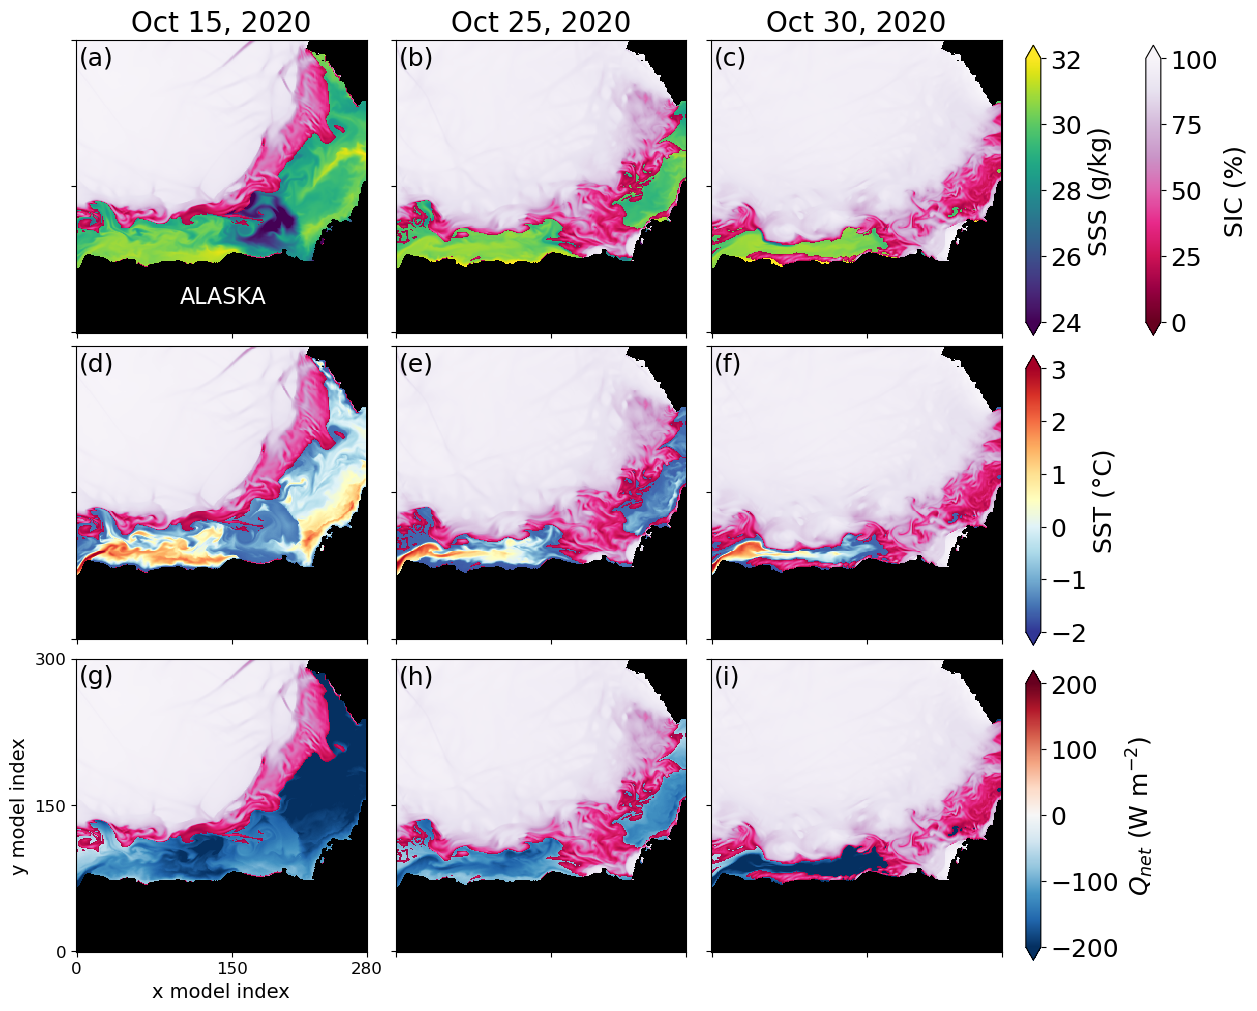

In [75]:
import string

dates = ['2020-10-15', '2020-10-25', '2020-10-30']
nrows, ncols = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 10), constrained_layout=True)
plt.rcParams.update({'font.size': 18})

# Add subplot labels (a)–(i)
for i, ax in enumerate(axes.flatten()):
    label = f"({string.ascii_lowercase[i]})"
    ax.text(0.01, 0.98, label, transform=ax.transAxes,
            fontsize=18, va='top', ha='left')

for col, date in enumerate(dates):
    # Load datasets
    SIarea_ds = (SIarea_zarr.sel(time=date).SIarea * 100).load()
    salt_ds = salt_zarr.sel(time=date).isel(k=0).SALT.load()
    theta_ds = theta_zarr.sel(time=date).isel(k=0).THETA.load()
    qnet_ds = (qnet_zarr.sel(time=date).EXFqnet * -1).load()

    # Mask ice-covered areas
    SIarea_over15 = SIarea_ds.where(SIarea_ds > 15, np.nan)
    salt_ice_mask = salt_ds.where(SIarea_ds < 15, np.nan)
    temp_ice_mask = theta_ds.where(SIarea_ds < 15, np.nan)
    qnet_ice_mask = qnet_ds.where(SIarea_ds < 15, np.nan)

    # Crop and rotate
    i_slice = slice(450, 750)
    j_slice = slice(110, 390)
    salt_flip = xr.DataArray(np.rot90(salt_ice_mask.isel(i=i_slice, j=j_slice).squeeze(), 3), dims=['i', 'j'])
    temp_flip = xr.DataArray(np.rot90(temp_ice_mask.isel(i=i_slice, j=j_slice).squeeze(), 3), dims=['i', 'j'])
    qnet_flip = xr.DataArray(np.rot90(qnet_ice_mask.isel(i=i_slice, j=j_slice).squeeze(), 3), dims=['i', 'j'])
    si_flip = xr.DataArray(np.rot90(SIarea_over15.isel(i=i_slice, j=j_slice).squeeze(), 3), dims=['i', 'j'])

    # Get axes
    ax1 = axes[0, col]
    ax2 = axes[1, col]
    ax3 = axes[2, col]

    # SSS
    salt_plot = salt_flip.plot(ax=ax1, vmin=24, vmax=32, cmap='viridis', add_colorbar=False)
    si_plot = si_flip.plot(ax=ax1, vmin=0, vmax=100, cmap='PuRd_r', add_colorbar=False)
    # ax1.set_title(date,size=20)

    # SST
    temp_plot = temp_flip.plot(ax=ax2, vmin=-2, vmax=3, cmap='RdYlBu_r', add_colorbar=False)
    si_flip.plot(ax=ax2, vmin=0, vmax=100, cmap='PuRd_r', add_colorbar=False)

    # Qnet
    qnet_plot = qnet_flip.plot(ax=ax3, vmin=-200, vmax=200, cmap='RdBu_r', add_colorbar=False)
    si_flip.plot(ax=ax3, vmin=0, vmax=100, cmap='PuRd_r', add_colorbar=False)

    for ax in [ax1, ax2, ax3]:
        ax.set_facecolor('k')
        ax.set_yticks([0,150,300])
        ax.set_xticks([0,150,280])
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        # ax.tick_params(left=False, bottom=False)

axes[-1, 0].set_xlabel('x model index',size=14)
axes[-1, 0].set_ylabel('y model index',size=14)
axes[-1, 0].set_xticklabels([0,150,280],size=12)
axes[-1, 0].set_yticklabels([0,150,300],size=12)
axes[-1, 1].set_xticklabels(["", "", "   "])

axes[0, 0].set_title("Oct 15, 2020",size=20)
axes[0, 1].set_title("Oct 25, 2020",size=20)
axes[0, 2].set_title("Oct 30, 2020",size=20)

axes[0, 0].text(100, 30, 'ALASKA', size=16, color='white')

# Row labels
# axes[0, 0].set_ylabel("SSS", fontsize=14)
# axes[1, 0].set_ylabel("SST", fontsize=14)
# axes[2, 0].set_ylabel("Qnet", fontsize=14)

# Colorbars
cbar_ax1 = fig.add_axes([1.02, 0.67, 0.015, 0.29]) # [left, bottom, width, height]
cbar1 = fig.colorbar(salt_plot, cax=cbar_ax1, extend='both')
cbar1.set_ticks([24, 26, 28, 30, 32])
cbar1.set_label("SSS (g/kg)")

cbar_ax2 = fig.add_axes([1.14, 0.67, 0.015, 0.29])
cbar2 = fig.colorbar(si_plot, cax=cbar_ax2, extend='both')
cbar2.set_ticks([0, 25, 50, 75, 100])
cbar2.set_label("SIC (%)")

cbar_ax3 = fig.add_axes([1.02, 0.36, 0.015, 0.29])
cbar3 = fig.colorbar(temp_plot, cax=cbar_ax3, extend='both')
cbar3.set_ticks([-2, -1, 0, 1, 2, 3])
cbar3.set_label("SST (°C)")

cbar_ax4 = fig.add_axes([1.02, 0.045, 0.015, 0.29])
cbar4 = fig.colorbar(qnet_plot, cax=cbar_ax4, extend='both')
cbar4.set_ticks([-200, -100, 0, 100, 200])
cbar4.set_label("$Q_{net}$ (W m$^{-2})$")

# save figure
plt.savefig("/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/multipanel_snapshot_202010.png", dpi=300, bbox_inches='tight')

plt.show()